# <center>Support Vector Machine (SVM)

## Table of Algorithms
### Linear SVM
1. Hard-margin SVM (SGD)
2. Soft-margin SVM (GD) 
3. Soft-margin SVM (SGD)
4. Soft-margin SVM (Mini-batch GD)
### Kernel SVM
5. Kernel SVM (RBF)

---

Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hard_margin_sgd import hinge_loss
from soft_margin_gd import hinge_loss_C

Importing data

In [2]:
import os
os.path.abspath(os.path.join(os.path.dirname('02_logistic_regression'), '..'))

bezdekIris = '../data/iris/bezdekIris.data'
df = pd.read_csv(bezdekIris)

---

Checking data

In [3]:
df

,5.1,3.5,1.4,0.2,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

df

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,Iris-setosa
1,4.7,3.2,1.3,0.2,Iris-setosa
2,4.6,3.1,1.5,0.2,Iris-setosa
3,5.0,3.6,1.4,0.2,Iris-setosa
4,5.4,3.9,1.7,0.4,Iris-setosa
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,Iris-virginica
145,6.3,2.5,5.0,1.9,Iris-virginica
146,6.5,3.0,5.2,2.0,Iris-virginica
147,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
df['class'].unique()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [6]:
df['class'] = df['class'].map({'Iris-setosa': 1, 
                               'Iris-versicolor': -1, 
                               'Iris-virginica': -1})

In [7]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

In [8]:
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,4.9,3.0,1.4,0.2,1
1,4.7,3.2,1.3,0.2,1
2,4.6,3.1,1.5,0.2,1
3,5.0,3.6,1.4,0.2,1
4,5.4,3.9,1.7,0.4,1
...,...,...,...,...,...
144,6.7,3.0,5.2,2.3,-1
145,6.3,2.5,5.0,1.9,-1
146,6.5,3.0,5.2,2.0,-1
147,6.2,3.4,5.4,2.3,-1


---

Visualizing data

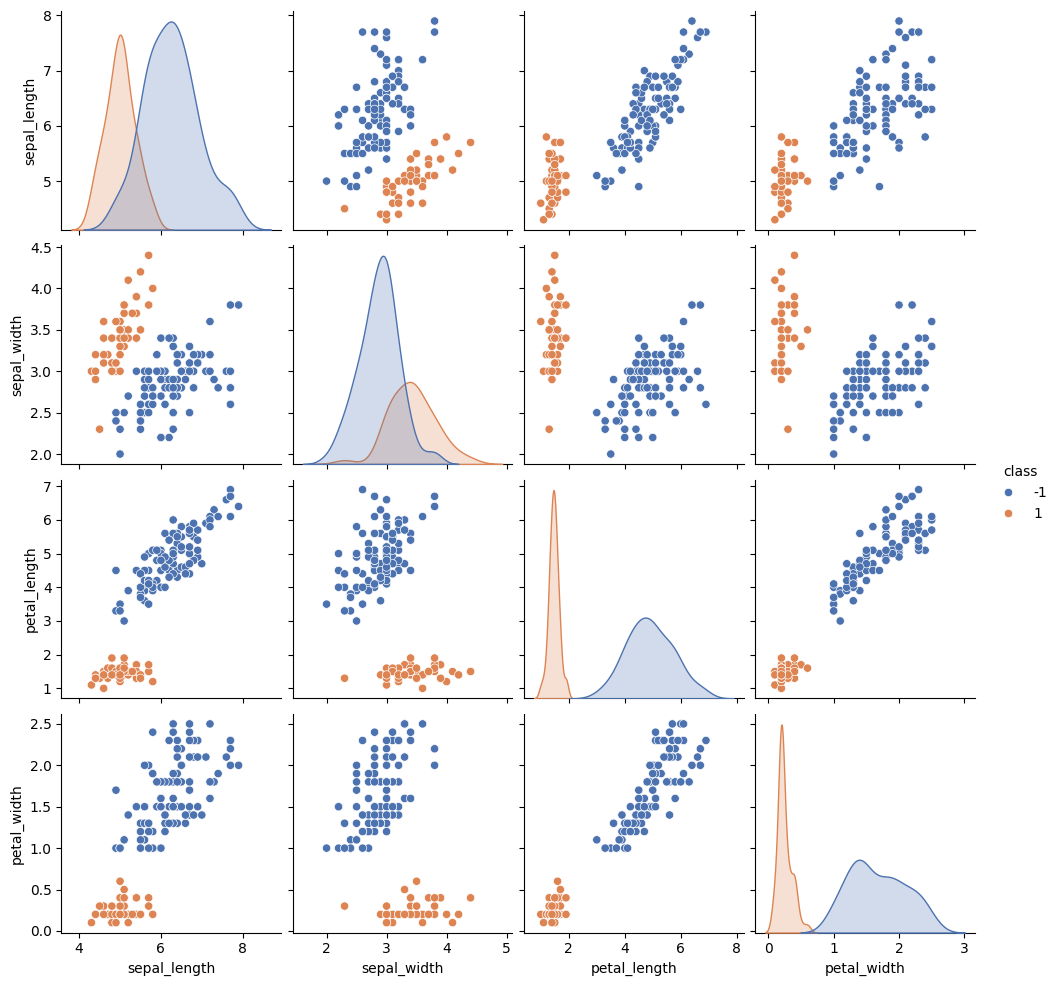

In [9]:
sns.pairplot(data=df, hue='class', palette='deep')

---

### **Hard margin stochastic gradient descent**

For 0 epoch
Loss: [0.46541163]
For 1 epoch
Loss: [0.45091281]
For 2 epoch
Loss: [0.44738532]
For 3 epoch
Loss: [0.44030851]
For 4 epoch
Loss: [0.43323129]
For 5 epoch
Loss: [0.42615366]
For 6 epoch
Loss: [0.41908752]
For 7 epoch
Loss: [0.41360306]
For 8 epoch
Loss: [0.40635086]
For 9 epoch
Loss: [0.39920406]
For 10 epoch
Loss: [0.39206975]
For 11 epoch
Loss: [0.3864227]
For 12 epoch
Loss: [0.37911024]
For 13 epoch
Loss: [0.37191076]
For 14 epoch
Loss: [0.36616665]
For 15 epoch
Loss: [0.35885293]
For 16 epoch
Loss: [0.35299461]
For 17 epoch
Loss: [0.34557938]
For 18 epoch
Loss: [0.33821606]
For 19 epoch
Loss: [0.33230445]
For 20 epoch
Loss: [0.32498705]
For 21 epoch
Loss: [0.317724]
For 22 epoch
Loss: [0.31175502]
For 23 epoch
Loss: [0.30449131]
For 24 epoch
Loss: [0.29724755]
For 25 epoch
Loss: [0.2912062]
For 26 epoch
Loss: [0.28399371]
For 27 epoch
Loss: [0.27792546]
For 28 epoch
Loss: [0.27067019]
For 29 epoch
Loss: [0.26458483]
For 30 epoch
Loss: [0.25731607]
For 31 epoch
Loss: [0.

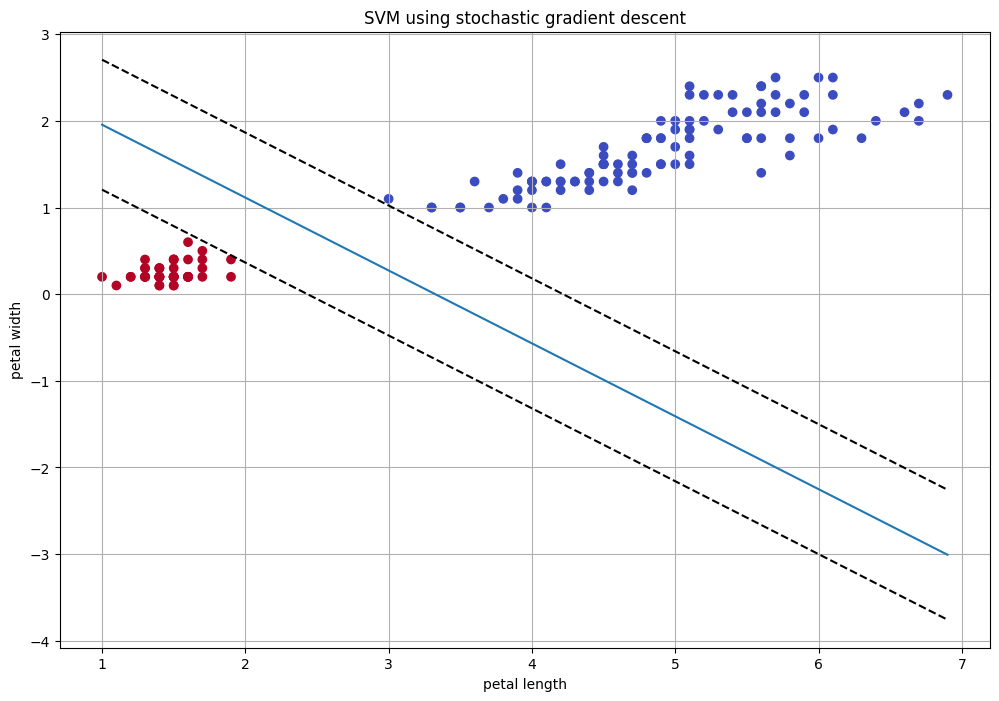

In [10]:
from hard_margin_sgd import Hard_margin_SGD

X = df[['petal_length', 'petal_width']].to_numpy()

y = df['class'].to_numpy()

hard_margin_sgd = Hard_margin_SGD()
hard_margin_sgd.fit(X, y, max_iters=1000, lr=0.001, stats=True)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('SVM using stochastic gradient descent')

w1 = hard_margin_sgd.weights[0]
w2 = hard_margin_sgd.weights[1]
b = hard_margin_sgd.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)
plt.plot(x1, x2 + 0.75, '--', color='black')
plt.plot(x1, x2 - 0.75, '--', color='black')

---

### **Soft margin gradient descent**

For 0 epochs loss:
76.19942609630294
For 1 epochs loss:
76.17258558805223
For 2 epochs loss:
73.44770885572417
For 3 epochs loss:
77.96147902716565
For 4 epochs loss:
70.69649859295745
For 5 epochs loss:
79.75023979160167
For 6 epochs loss:
67.94579516919063
For 7 epochs loss:
81.53886787047985
For 8 epochs loss:
65.31830394667692
For 9 epochs loss:
79.83563354170685
For 10 epochs loss:
66.36336432903195
For 11 epochs loss:
81.62413653993114
For 12 epochs loss:
64.1085847414793
For 13 epochs loss:
74.3440967325927
For 14 epochs loss:
70.99780018269705
For 15 epochs loss:
76.13268843738933
For 16 epochs loss:
68.24869413833774
For 17 epochs loss:
77.92114734761898
For 18 epochs loss:
65.54017054816997
For 19 epochs loss:
77.52362937055013
For 20 epochs loss:
65.27146736138815
For 21 epochs loss:
77.12605416921078
For 22 epochs loss:
65.00432006161844
For 23 epochs loss:
76.29660039463256
For 24 epochs loss:
65.17088224003936
For 25 epochs loss:
75.89892887348573
For 26 epochs loss:
64.9

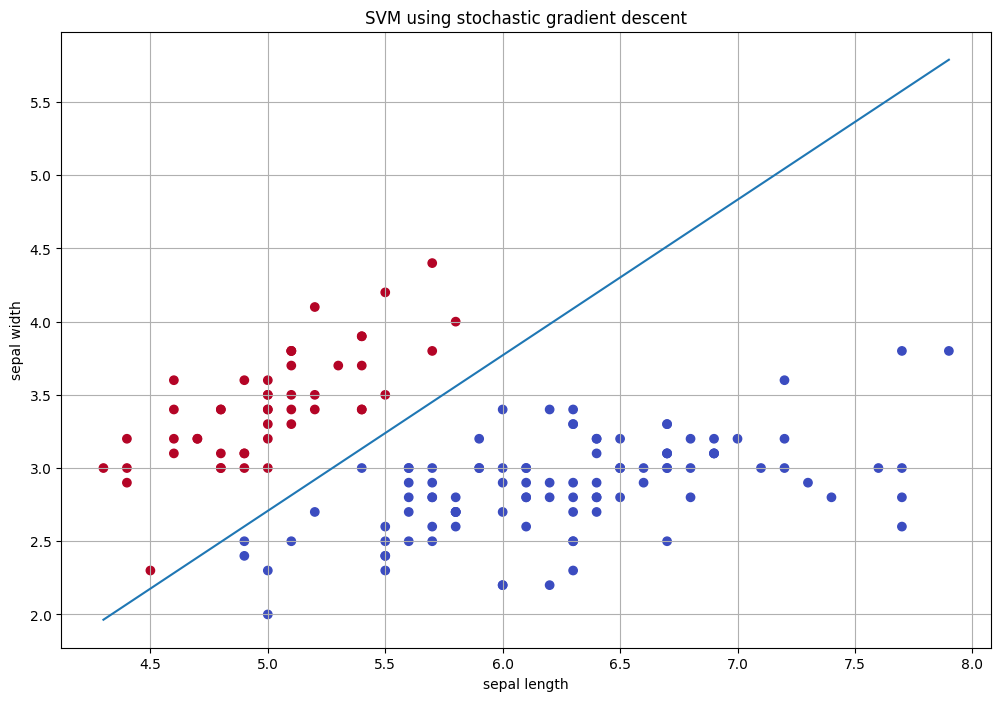

In [11]:
from soft_margin_gd import Soft_margin_GD
X = df[['sepal_length', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()
soft_margin_gd = Soft_margin_GD()
soft_margin_gd.fit(X, y, max_iters=1000, lr=0.0001, stats=True, C=100)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('SVM using stochastic gradient descent')

w1 = soft_margin_gd.weights[0]
w2 = soft_margin_gd.weights[1]
b = soft_margin_gd.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)

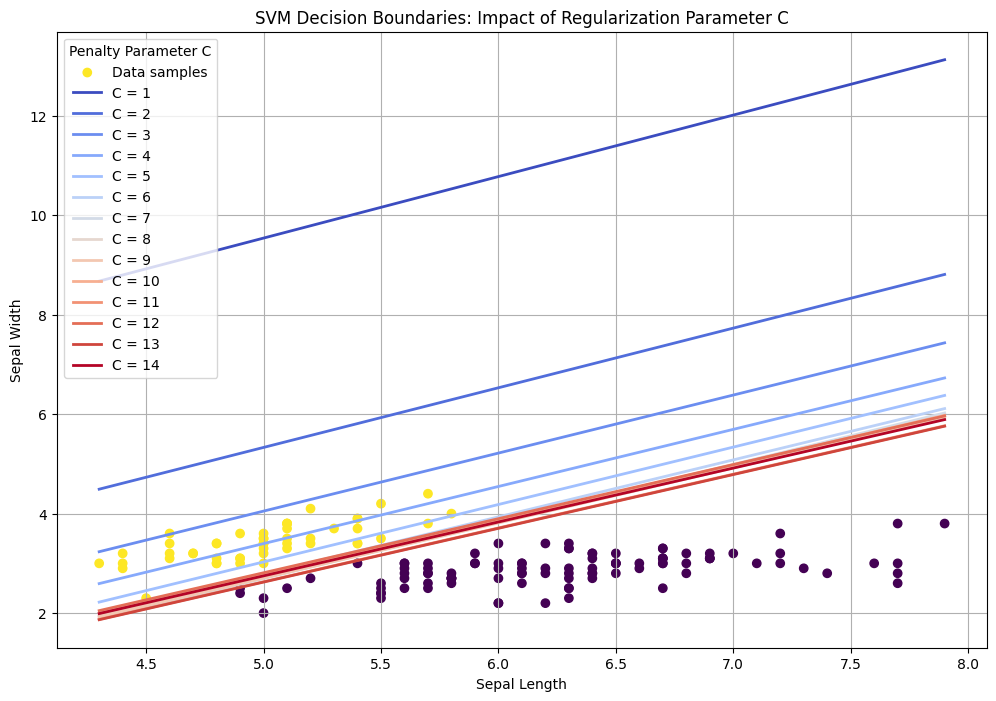

In [12]:
# === C test ===
X = df[['sepal_length', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()


cs = [i for i in range(1, 15)]
c_test = Soft_margin_GD()

num_plots = len(cs)
colormap = plt.cm.coolwarm
colors = [colormap(i) for i in np.linspace(0, 1, num_plots)]

plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='Data samples')

loss_test = []

for idx, c in enumerate(cs):
    c_test.fit(X, y, max_iters=1000, lr=0.001, stats=False, C=c)

    w = c_test.weights.flatten()
    b = c_test.bias

    a_slope = -(w[0] / w[1])
    intercept = -(b / w[1])

    x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_vals = (a_slope * x_vals) + intercept
    
    plt.plot(x_vals, y_vals, label=f'C = {c}', color=colors[idx], linewidth=2)

    current_loss = hinge_loss(X, y, c_test.weights, c_test.bias) 
    loss_test.append(current_loss)

plt.title('SVM Decision Boundaries: Impact of Regularization Parameter C',)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(title="Penalty Parameter C")
plt.grid()


---

### **Soft margin stochastic gradient descent**

For 0 epochs loss:
1.767110044611053
For 1 epochs loss:
0.9322890794380153
For 2 epochs loss:
0.9540878247851289
For 3 epochs loss:
0.8428260499503457
For 4 epochs loss:
0.8839245338899941
For 5 epochs loss:
1.7578101097037206
For 6 epochs loss:
0.840831558458368
For 7 epochs loss:
0.8221102966334752
For 8 epochs loss:
1.6234119185319495
For 9 epochs loss:
1.1446993492088373
For 10 epochs loss:
1.3462024478928782
For 11 epochs loss:
0.8357880405683094
For 12 epochs loss:
1.03164866718266
For 13 epochs loss:
0.8085835500847458
For 14 epochs loss:
0.8700844379139614
For 15 epochs loss:
0.775722189953876
For 16 epochs loss:
0.9785888328716905
For 17 epochs loss:
0.7175943857000836
For 18 epochs loss:
1.4959366519827921
For 19 epochs loss:
0.7566394106957388
For 20 epochs loss:
2.0675398268917378
For 21 epochs loss:
0.9100682180124786
For 22 epochs loss:
0.758704960870305
For 23 epochs loss:
0.6949181333538756
For 24 epochs loss:
0.8445044581872291
For 25 epochs loss:
0.8146495021194189
Fo

(np.float64(0.5), np.float64(7.1), np.float64(4.0), np.float64(8.0))

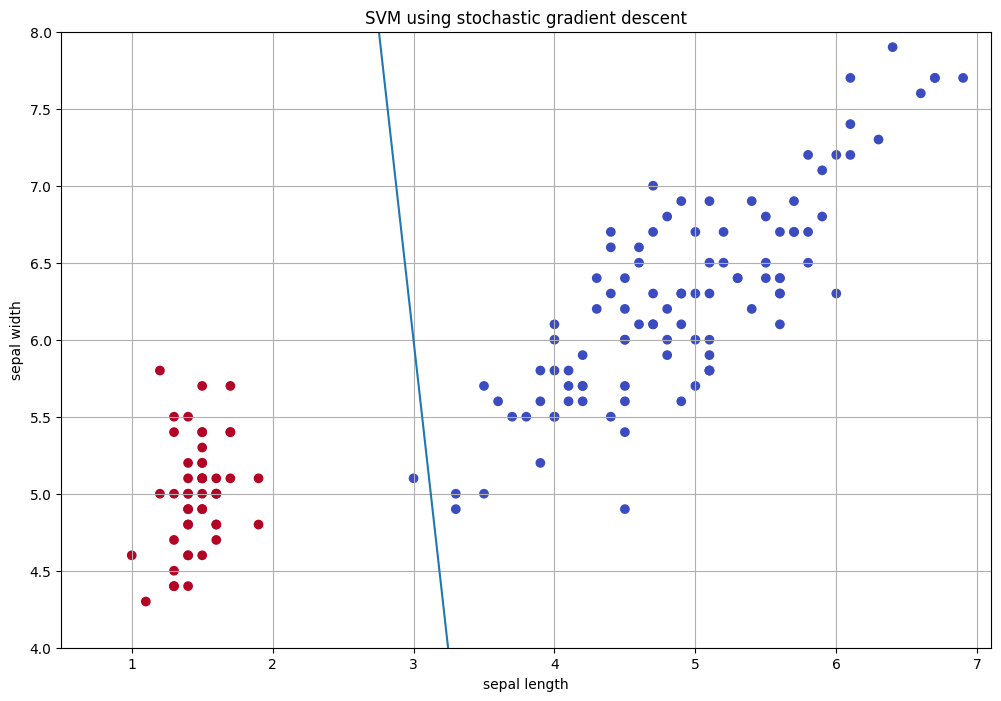

In [13]:
from soft_margin_sgd import Soft_margin_SGD
X = df[['petal_length', 'sepal_length']].to_numpy()
y = df['class'].to_numpy()
soft_margin_sgd = Soft_margin_SGD()
soft_margin_sgd.fit(X, y, max_iters=1000, lr=0.003, stats=True, C=8)


plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('SVM using stochastic gradient descent')

w1 = soft_margin_sgd.weights[0]
w2 = soft_margin_sgd.weights[1]
b = soft_margin_sgd.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)
plt.axis([0.5, 7.1, 4, 8])

---

### **Soft margin stochastic gradient descent**

For 0 epochs loss:
6.6343986882512285
For 1 epochs loss:
5.373683302840144
For 2 epochs loss:
5.024986977714696
For 3 epochs loss:
4.913135504384666
For 4 epochs loss:
4.808641680550407
For 5 epochs loss:
4.704612746767679
For 6 epochs loss:
4.666862121038522
For 7 epochs loss:
4.522859233464151
For 8 epochs loss:
4.441325836686858
For 9 epochs loss:
4.3354174738132985
For 10 epochs loss:
4.252557162756825
For 11 epochs loss:
4.1745182435606525
For 12 epochs loss:
4.091964732350897
For 13 epochs loss:
4.00958611104262
For 14 epochs loss:
3.9325642082470784
For 15 epochs loss:
3.857978713855005
For 16 epochs loss:
3.7838823590497124
For 17 epochs loss:
3.7119194236401274
For 18 epochs loss:
3.641026340593129
For 19 epochs loss:
3.5736374540398286
For 20 epochs loss:
3.5002825478567487
For 21 epochs loss:
3.4347367398768114
For 22 epochs loss:
3.3710362951509043
For 23 epochs loss:
3.3067668751804176
For 24 epochs loss:
3.2441672754132456
For 25 epochs loss:
3.1834012980605557
For 26 epo

(np.float64(0.0), np.float64(2.6), np.float64(1.8), np.float64(4.6))

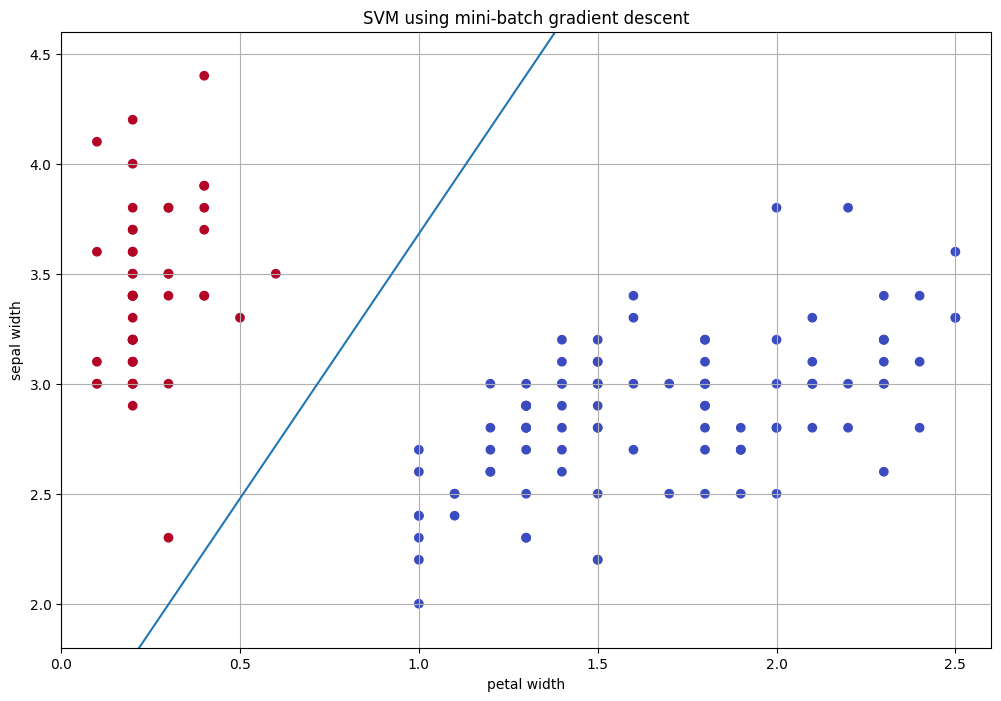

In [14]:
from soft_margin_mini import Soft_margin_MINI
X = df[['petal_width', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()
soft_margin_mini = Soft_margin_MINI()
soft_margin_mini.fit(X, y, max_iters=1000, lr=0.001, stats=True, C=8)

plt.figure(figsize=(12, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, label='data', cmap='coolwarm')
plt.grid()
plt.xlabel('petal width')
plt.ylabel('sepal width')
plt.title('SVM using mini-batch gradient descent')

w1 = soft_margin_mini.weights[0]
w2 = soft_margin_mini.weights[1]
b = soft_margin_mini.bias
a = -(w1 / w2)
intercept = -(b / w2)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x2 = (a * x1) + intercept
print(f'y = {a}x + {intercept}')

plt.plot(x1, x2)
plt.axis([0, 2.6, 1.8, 4.6])

---

### **Kernel SVM (RBF)** 

In [21]:
from kernel_svm_rbf import Kernel_svm_RBF

X = df[['petal_width', 'sepal_width']].to_numpy()
y = df['class'].to_numpy()

svm_rbf = Kernel_svm_RBF()
svm_rbf.fit(X, y, max_iters=100, stats=True, C=0.01, gamma=0.5)

Loss for 0 epochs: [[0.52753378]]
Loss for 1 epochs: [[0.80313203]]
Loss for 2 epochs: [[0.91140057]]
Loss for 3 epochs: [[0.97182645]]
Loss for 4 epochs: [[0.9922572]]
Loss for 5 epochs: [[1.01083724]]
Loss for 6 epochs: [[1.02681338]]
Loss for 7 epochs: [[1.03260652]]
Loss for 8 epochs: [[1.0628908]]
Loss for 9 epochs: [[1.06244711]]
Loss for 10 epochs: [[1.06293371]]
Loss for 11 epochs: [[1.07643524]]
Loss for 12 epochs: [[1.07457728]]
Loss for 13 epochs: [[1.06799462]]
Loss for 14 epochs: [[1.0736606]]
Loss for 15 epochs: [[1.07229523]]
Loss for 16 epochs: [[1.06671128]]
Loss for 17 epochs: [[1.07270018]]
Loss for 18 epochs: [[1.07270018]]
Loss for 19 epochs: [[1.07532462]]
Loss for 20 epochs: [[1.07151398]]
Loss for 21 epochs: [[1.07151398]]
Loss for 22 epochs: [[1.07151398]]
Loss for 23 epochs: [[1.07151398]]
Loss for 24 epochs: [[1.06683409]]
Loss for 25 epochs: [[1.06434593]]
Loss for 26 epochs: [[1.06434593]]
Loss for 27 epochs: [[1.06434593]]
Loss for 28 epochs: [[1.06434593]